# **1. K-Mean 1D**

## **Step-by-step implementation**

In [1]:
import numpy as np

In [2]:
X = np.array([1.4, 1.0, 1.5, 3.1, 3.7, 4.1])

In [6]:
k = 2
max_iters = 2 # iterations

# initialize centroids
centroids = X[:k]
print('Init centroids: ', centroids)

for _ in range(max_iters):
    distances = np.sqrt((X.reshape(-1, 1) - centroids)**2)
    print(distances)

    labels = np.argmin(distances, axis=1)
    print(labels)

    new_centroids = [X[labels == i].mean() for i in range(k)]

    if np.all(new_centroids == centroids):
        break
    centroids = new_centroids

    # print
    print("Labels:", labels)
    print("Centroids:", centroids)
    print()

wcss = np.sum([np.sum(np.square(X[labels == i] - centroids[i])) for i in range(k)])
print("WCSS:", wcss)


Init centroids:  [1.4 1. ]
[[0.  0.4]
 [0.4 0. ]
 [0.1 0.5]
 [1.7 2.1]
 [2.3 2.7]
 [2.7 3.1]]
[0 1 0 0 0 0]
Labels: [0 1 0 0 0 0]
Centroids: [np.float64(2.76), np.float64(1.0)]

[[1.36 0.4 ]
 [1.76 0.  ]
 [1.26 0.5 ]
 [0.34 2.1 ]
 [0.94 2.7 ]
 [1.34 3.1 ]]
[1 1 1 0 0 0]
Labels: [1 1 1 0 0 0]
Centroids: [np.float64(3.6333333333333333), np.float64(1.3)]

WCSS: 0.6466666666666663


## **Using sklearn**

In [12]:
from sklearn.cluster import KMeans

X = np.array([1.4, 1.0, 1.5, 3.1, 3.7, 4.1])

kmeans = KMeans(n_clusters=2)
kmeans.fit(X.reshape(-1, 1))
labels = kmeans.labels_
print(labels)
print(kmeans.inertia_)
print(kmeans.cluster_centers_.flatten())

for x, label in zip(X, labels):
    print(f"Cluster {label}: {x}")

[1 1 1 0 0 0]
0.6466666666666663
[3.63333333 1.3       ]
Cluster 1: 1.4
Cluster 1: 1.0
Cluster 1: 1.5
Cluster 0: 3.1
Cluster 0: 3.7
Cluster 0: 4.1


**Elbow method: Choose K optimal**

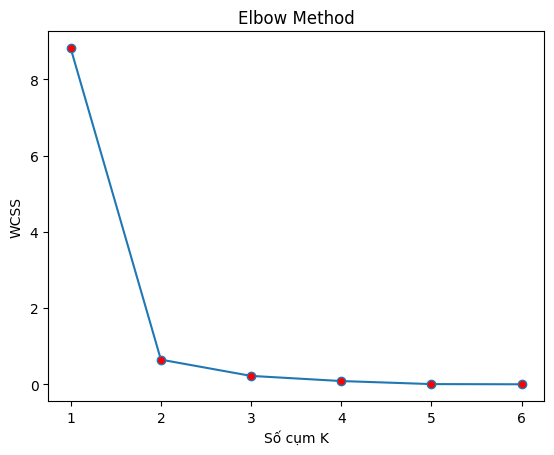

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss_values = []

X = np.array([1.4, 1.0, 1.5, 3.1, 3.7, 4.1]).reshape(-1, 1)

for k in range(1, len(X) + 1): # Max k should be <= number of samples
    kmean = KMeans(
        n_clusters = k,
        random_state=42,
        n_init=10
    )
    kmean.fit(X)
    wcss_values.append(kmean.inertia_)

plt.plot(range(1, len(X) + 1), wcss_values, marker="o", markerfacecolor='red')
plt.xlabel("Số cụm K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.xticks(range(1, len(X) + 1))
plt.show()

# **2. K-Mean 2D**

## **Step-by-step implementation**

In [13]:
import numpy as np

X = np.array(
    [
        [1.4, 0.2],
        [1.3, 0.4],
        [1.4, 0.3],
        [4.0, 1.0],
        [4.7, 1.4],
        [3.6, 1.3]
    ]
)

In [26]:
k = 2
max_iters = 2

# initialize centroids
centroids = X[:k]
print('Init centroids: ', centroids)

for _ in range(max_iters):
    # assign points
    distances = np.linalg.norm(X[:, np.newaxis, :] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    # update centroids
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

    # check for convergence
    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

    # print
    print("Labels:", labels)
    print("Centroids:", centroids)

# calculate WCSS
wcss = np.sum([np.sum(np.square(X[labels == i] - centroids[i])) for i in range(k)])
print("WCSS:", wcss)

Init centroids:  [[1.4 0.2]
 [1.3 0.4]]
Labels: [0 1 0 0 0 0]
Centroids: [[3.02 0.84]
 [1.3  0.4 ]]
Labels: [1 1 1 0 0 0]
Centroids: [[4.1        1.23333333]
 [1.36666667 0.3       ]]
WCSS: 0.7333333333333334


## **Using sklearn**

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
kmeans.fit(X.reshape(-1, 2))
labels = kmeans.labels_

print(labels)
print(kmeans.inertia_)

for x, label in zip(X, labels):
    print(f"Cluster {label}: {x}")

[1 1 1 0 0 0]
0.7333333333333335
Cluster 1: [1.4 0.2]
Cluster 1: [1.3 0.4]
Cluster 1: [1.4 0.3]
Cluster 0: [4. 1.]
Cluster 0: [4.7 1.4]
Cluster 0: [3.6 1.3]


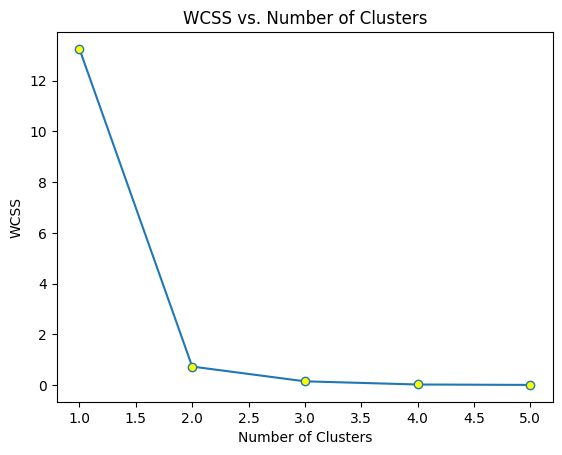

In [29]:
import matplotlib.pyplot as plt

wcss_values = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X.reshape(-1, 2))
    wcss = kmeans.inertia_
    wcss_values.append(wcss)

plt.plot(range(1, 6), wcss_values, marker='o', markerfacecolor='yellow')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters')
plt.show()

# **3. Image in K-mean**

## **Don't use pretrained model (magic function)**

In [40]:
import numpy as np
import os
import cv2

def load_images_from_folder(folder):
    data = []
    for filename in os.listdir(folder):
        if filename.lower().endswith('.jpg'):
            img = cv2.imread(os.path.join(folder, filename))
            data.append(img)
    return data

dog_images = np.array(load_images_from_folder('/content/training/dog'))
cat_images = np.array(load_images_from_folder('/content/training/cat'))

In [43]:
print(dog_images.shape)
print(cat_images.shape)

(10, 224, 224, 3)
(10, 224, 224, 3)


In [51]:
from sklearn.cluster import KMeans

merged_features = np.concatenate((dog_images.reshape(10, -1), cat_images.reshape(10, -1)), axis = 0)

kmeans = KMeans(n_clusters=2).fit(merged_features)

In [54]:
kmeans.labels_

# phân cụm bị lỗi --> vì có những đặc trưng của ảnh không có ý nghĩa ví dụ như background

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

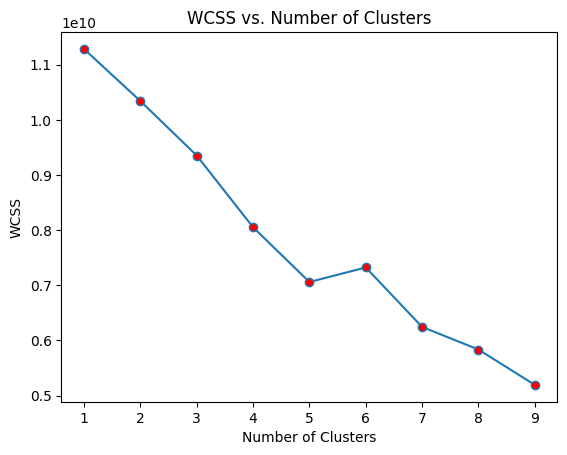

In [55]:
import matplotlib.pyplot as plt

wcss_values = []
for i in range(1, 10):
   kmeans = KMeans(n_clusters=i).fit(merged_features)
   wcss_values.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss_values, marker='o', markerfacecolor='red')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters')
plt.show()

## **Using pretrained model (CLIP MODEL)**

In [94]:
import numpy as np
import os
import cv2

labels = []
def load_images_from_folder(folder):
    data = []
    for filename in os.listdir(folder):
        if filename.lower().endswith('.jpg'):
            img = cv2.imread(os.path.join(folder, filename))
            data.append(img)

            labels.append(filename)
    return data

dog_images = np.array(load_images_from_folder('/content/training/dog'))
cat_images = np.array(load_images_from_folder('/content/training/cat'))

In [95]:
# use it as a magic tool
from transformers import CLIPProcessor, CLIPModel
import torch

clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

# CLIP
def magic_function(images):
    inputs = clip_processor(
        images=images,
        return_tensors="pt"
    )

    with torch.inference_mode():
        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        # Tensor biểu diễn tổng quát của mỗi ảnh
        pooled_output = vision_outputs.pooler_output

        # Chiếu sang không gian CLIP embedding
        features = clip_model.visual_projection(pooled_output)

        # Chuẩn hóa độ dài mỗi vector về 1
        features = features / features.norm(
            p=2,
            dim=1,
            keepdim=True
        )

    return features.cpu().numpy()

dog_images_features = magic_function(list(dog_images))
cat_images_features = magic_function(list(cat_images))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [96]:
print(dog_images_features.shape)
print(cat_images_features.shape)

(10, 512)
(10, 512)


In [97]:
merged_features = np.concatenate((dog_images_features, cat_images_features), axis=0)
print(merged_features.shape)

(20, 512)


In [101]:
from sklearn.cluster import KMeans

# KMeans
kmeans = KMeans(n_clusters=2, init="k-means++", random_state=0, n_init=20).fit(merged_features)
print(kmeans.labels_)

for real_label, predicted_label in zip(labels, kmeans.labels_):
    print(f"Cluster {predicted_label}: {real_label}")

[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1]
Cluster 0: dog.5.jpg
Cluster 0: dog.8.jpg
Cluster 0: dog.0.jpg
Cluster 0: dog.9.jpg
Cluster 0: dog.1.jpg
Cluster 0: dog.3.jpg
Cluster 0: dog.6.jpg
Cluster 0: dog.4.jpg
Cluster 0: dog.2.jpg
Cluster 1: dog.7.jpg
Cluster 1: cat.6.jpg
Cluster 1: cat.0.jpg
Cluster 1: cat.7.jpg
Cluster 1: cat.1.jpg
Cluster 1: cat.9.jpg
Cluster 1: cat.8.jpg
Cluster 1: cat.2.jpg
Cluster 1: cat.4.jpg
Cluster 1: cat.3.jpg
Cluster 1: cat.5.jpg


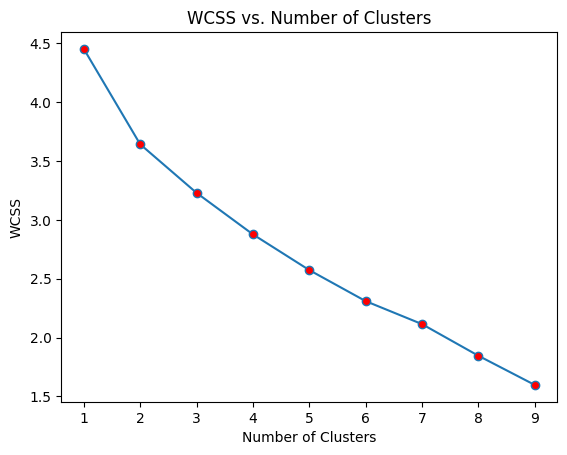

In [102]:
import matplotlib.pyplot as plt

wcss_values = []
for i in range(1, 10):
   kmeans = KMeans(n_clusters=i, init="k-means++", random_state=0, n_init=20).fit(merged_features)
   wcss_values.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss_values, marker='o', markerfacecolor='red')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters')
plt.show()

# **4. Text Classification**

## **Dont magic function**

In [104]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [105]:
vectorizer = CountVectorizer()
corpus = ["hãy sống hết mình mỗi ngày như thể đó là ngày cuối cùng của hành trình cuộc đời và hãy học hỏi như thể bạn sẽ sống mãi mãi",
          "hãy tin tưởng vào bản thân và vào hành trình cuộc sống mọi điều sẽ trở nên tốt đẹp hơn khi bạn có lòng tin",
          "cuộc sống không chờ đợi mưa ngừng mà là việc học cách sống vui vẻ dưới cơn mưa",
          "học toán online hiệu quả với hàng ngàn video bài giảng, bài tập luyện tập từ cơ bản đến nâng cao",
          "trong chuyên mục 5 phút học toán hôm nay, thầy Hiếu giới thiệu bài toán rất hay và khó về tính tổng các chữ số",
          "với tâm trí quyết tâm và không bỏ cuộc rằng ước mơ sẽ hóa thành sự thật",

          "unlike Icelandic and Faroese which were isolated the development of English was influenced by a long series of invasions",
          "these left a profound mark of their own on the language so that English shows some similarities in vocabulary",
          "typical wiki contains multiple pages that can either be edited by the public or limited to use within an organization for",
          "have little inherent structure, allowing one to emerge according to the needs of the users",
          "hosting user-authored content wikis allow those users to interact, hold discussions and collaborate",
          "English is classified as a Germanic language because it shares innovations with other Germanic languages"]

X = vectorizer.fit_transform(corpus)

In [106]:
print(vectorizer.vocabulary_)

{'hãy': 54, 'sống': 127, 'hết': 58, 'mình': 87, 'mỗi': 91, 'ngày': 97, 'như': 99, 'thể': 139, 'đó': 179, 'là': 81, 'cuối': 24, 'cùng': 29, 'của': 32, 'hành': 53, 'trình': 145, 'cuộc': 25, 'đời': 181, 'và': 164, 'học': 59, 'hỏi': 60, 'bạn': 12, 'sẽ': 125, 'mãi': 86, 'tin': 140, 'tưởng': 153, 'vào': 165, 'bản': 13, 'thân': 136, 'mọi': 90, 'điều': 177, 'trở': 147, 'nên': 101, 'tốt': 154, 'đẹp': 180, 'hơn': 57, 'khi': 71, 'có': 28, 'lòng': 82, 'không': 73, 'chờ': 18, 'đợi': 182, 'mưa': 89, 'ngừng': 98, 'mà': 85, 'việc': 161, 'cách': 27, 'vui': 163, 'vẻ': 167, 'dưới': 35, 'cơn': 31, 'ho': 50, 'toa': 142, 'online': 105, 'hiê': 48, 'qua': 114, 'vơ': 166, 'ha': 45, 'ng': 95, 'nga': 96, 'video': 160, 'ba': 7, 'gia': 43, 'tâ': 149, 'luyê': 80, 'tư': 152, 'cơ': 30, 'đê': 178, 'nâng': 100, 'cao': 16, 'trong': 144, 'chuyên': 17, 'mục': 92, 'phút': 111, 'toán': 143, 'hôm': 56, 'nay': 93, 'thầy': 137, 'hiếu': 49, 'giới': 44, 'thiệu': 133, 'bài': 11, 'rất': 116, 'hay': 47, 'khó': 72, 'về': 168, 'tính'

In [107]:
X = X.toarray()
print(X[0])

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 2 1 0 0 0 1 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]


In [108]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)
labels = kmeans.labels_

print(labels)
print(kmeans.inertia_)

for sentence, label in zip(corpus, labels):
    print(f"Cluster {label}: {sentence[:50]}...")

[1 1 1 1 1 1 0 0 0 0 0 0]
211.66666666666669
Cluster 1: hãy sống hết mình mỗi ngày như thể đó là ngày cuối...
Cluster 1: hãy tin tưởng vào bản thân và vào hành trình cuộc ...
Cluster 1: cuộc sống không chờ đợi mưa ngừng mà là việc học c...
Cluster 1: học toán online hiệu quả với hàng ngàn vide...
Cluster 1: trong chuyên mục 5 phút học toán hôm nay, thầy Hiế...
Cluster 1: với tâm trí quyết tâm và không bỏ cuộc rằng ước mơ...
Cluster 0: unlike Icelandic and Faroese which were isolated t...
Cluster 0: these left a profound mark of their own on the lan...
Cluster 0: typical wiki contains multiple pages that can eith...
Cluster 0: have little inherent structure, allowing one to em...
Cluster 0: hosting user-authored content wikis allow those us...
Cluster 0: English is classified as a Germanic language becau...


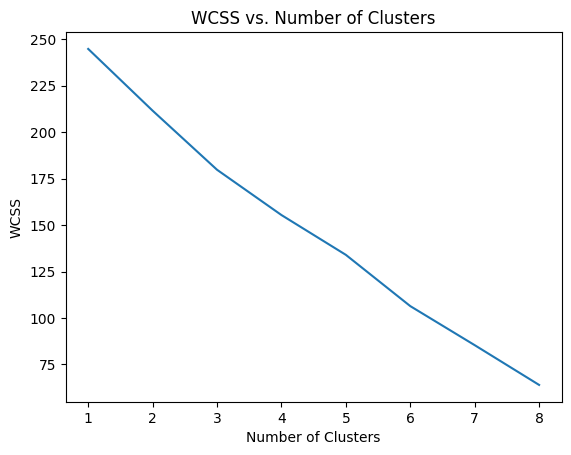

In [109]:
import matplotlib.pyplot as plt

wcss_values = []
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss = kmeans.inertia_
    wcss_values.append(wcss)

plt.plot(range(1, 9), wcss_values)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters')
plt.show()

## **Use magic function**

In [115]:
def magic_function(corpus):
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    inputs = processor(
        text=corpus,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    with torch.inference_mode():
        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        pooled_output = text_outputs.pooler_output

        text_features = model.text_projection(
            pooled_output
        )

        # Chuẩn hóa embedding
        text_features = text_features / text_features.norm(
            p=2,
            dim=1,
            keepdim=True
        )

    return text_features.cpu().numpy()

In [116]:
import numpy as np
from sklearn.cluster import KMeans

# get new features
text_features = magic_function(corpus)

kmeans = KMeans(n_clusters=2)
kmeans.fit(text_features)

# print
for sentence, label in zip(corpus, kmeans.labels_):
    print(f"Cluster {label}: {sentence[:50]}...")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Cluster 1: hãy sống hết mình mỗi ngày như thể đó là ngày cuối...
Cluster 1: hãy tin tưởng vào bản thân và vào hành trình cuộc ...
Cluster 1: cuộc sống không chờ đợi mưa ngừng mà là việc học c...
Cluster 1: học toán online hiệu quả với hàng ngàn vide...
Cluster 1: trong chuyên mục 5 phút học toán hôm nay, thầy Hiế...
Cluster 1: với tâm trí quyết tâm và không bỏ cuộc rằng ước mơ...
Cluster 0: unlike Icelandic and Faroese which were isolated t...
Cluster 0: these left a profound mark of their own on the lan...
Cluster 0: typical wiki contains multiple pages that can eith...
Cluster 0: have little inherent structure, allowing one to em...
Cluster 0: hosting user-authored content wikis allow those us...
Cluster 0: English is classified as a Germanic language becau...


Text(0.5, 1.0, 'WCSS vs. Number of Clusters (CLIP embeddings)')

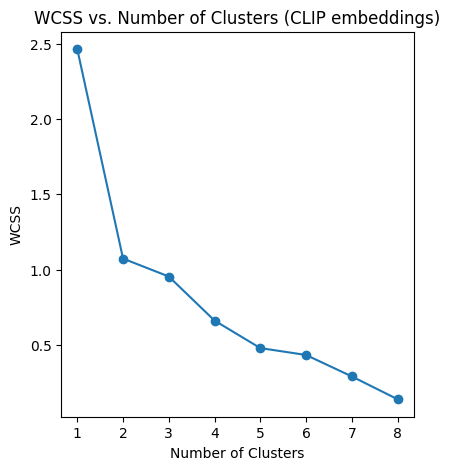

In [117]:
import matplotlib.pyplot as plt

#  WCSS
wcss_values = []
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(text_features)
    wcss_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 9), wcss_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters (CLIP embeddings)')